# LemoScan AI | Dataset integrity audit

**Purpose:** establish a reproducible dataset baseline before further training.
This notebook reads dataset files and writes reports only to `reports/dataset_audit/`.
It never deletes, moves, renames, repairs, or rewrites dataset files and never loads or trains a model.

**Evidence levels:** SHA-256 matches establish byte-identical files. Difference-hash similarity and filename patterns only identify candidates requiring human verification; they do not prove leakage or shared capture identity.

Run all cells in order. Dependencies: Python, NumPy, Pandas, Pillow, Matplotlib, and IPython (included with a Jupyter kernel). No package installation is performed.


## 1. Dataset configuration and reproducibility
The root is discovered by walking upward from the kernel working directory, requiring both `dataset/` and `utils/model_loader.py`. If your kernel starts elsewhere, set `PROJECT_ROOT_OVERRIDE` explicitly. Classes are discovered across all three splits, including empty directories. Supported image extensions are listed below; other files are reported separately.


In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import hashlib
import json
import platform
import random
import re
import warnings
import importlib.metadata as metadata

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, UnidentifiedImageError
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
PROJECT_ROOT_OVERRIDE = None  # Example: Path(r"E:\LemoScan-AI")
SPLITS = ("train", "val", "test")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".gif"}
DHASH_SIZE = 8
NEAR_DISTANCE_MAX = 6  # 0-64 differing bits; a screening threshold, not a probability.
MAX_REVIEW_PAIRS = 8
MIN_DIMENSION = 80
MAX_DIMENSION = 6000
MAX_ASPECT_RATIO = 3.0
CAPTURE_NUMBER_GAP = 1


def resolve_project_root(override=None):
    candidates = [Path(override).expanduser().resolve()] if override else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / "dataset").is_dir() and (candidate / "utils/model_loader.py").is_file():
            return candidate
    raise FileNotFoundError("Project root not found. Set PROJECT_ROOT_OVERRIDE to the LemoScan-AI folder.")


PROJECT_ROOT = resolve_project_root(PROJECT_ROOT_OVERRIDE)
DATASET_ROOT = PROJECT_ROOT / "dataset"
REPORT_DIR = PROJECT_ROOT / "reports/dataset_audit"
if REPORT_DIR.resolve().is_relative_to(DATASET_ROOT.resolve()):
    raise ValueError("Reports must not be written inside the dataset.")
REPORT_DIR.mkdir(parents=True, exist_ok=True)
missing_splits = [split for split in SPLITS if not (DATASET_ROOT / split).is_dir()]
if missing_splits:
    raise FileNotFoundError(f"Missing required splits: {missing_splits}")
CLASSES = sorted({p.name for split in SPLITS for p in (DATASET_ROOT / split).iterdir() if p.is_dir()})
versions = {name: metadata.version(name) for name in ("numpy", "pandas", "Pillow", "matplotlib", "ipython")}
print("Project:", PROJECT_ROOT)
print("Discovered classes:", CLASSES)
print("Python:", platform.python_version())
display(pd.Series(versions, name="version").to_frame())


Project: E:\LemoScan-AI
Discovered classes: ['Algal leaf spot', 'Black spot', 'Citrus canker', 'Citrus pest', 'Greening', 'Healthy leaf', 'Not lemon leaf']
Python: 3.13.2


,version
numpy,2.3.4
pandas,2.3.3
Pillow,11.3.0
matplotlib,3.10.7
ipython,9.6.0


In [2]:
def sorted_files(folder):
    return sorted((p for p in folder.rglob("*") if p.is_file()), key=lambda p: p.as_posix())


folder_rows, file_records, non_image_rows = [], [], []
for split in SPLITS:
    for class_name in CLASSES:
        folder = DATASET_ROOT / split / class_name
        files = sorted_files(folder) if folder.is_dir() else []
        images = [p for p in files if p.suffix.lower() in IMAGE_EXTENSIONS]
        folder_rows.append({"split": split, "class": class_name, "exists": folder.is_dir(),
                            "image_count": len(images), "other_file_count": len(files) - len(images),
                            "empty_class": folder.is_dir() and not images})
        file_records.extend((split, class_name, p) for p in images)
        non_image_rows.extend({"filepath": p.relative_to(PROJECT_ROOT).as_posix(), "reason": "non-image extension"}
                              for p in files if p.suffix.lower() not in IMAGE_EXTENSIONS)
    non_image_rows.extend({"filepath": p.relative_to(PROJECT_ROOT).as_posix(), "reason": "file outside class folder"}
                          for p in sorted((DATASET_ROOT / split).iterdir()) if p.is_file())
folder_inventory = pd.DataFrame(folder_rows, columns=["split", "class", "exists", "image_count", "other_file_count", "empty_class"])
non_image_files = pd.DataFrame(non_image_rows, columns=["filepath", "reason"])
folder_inventory.to_csv(REPORT_DIR / "class_folder_inventory.csv", index=False)
non_image_files.to_csv(REPORT_DIR / "non_image_files.csv", index=False)
display(folder_inventory)
print("Empty class folders (no supported images):")
display(folder_inventory.loc[folder_inventory["empty_class"], ["split", "class", "other_file_count"]])
print("Missing class folders:")
display(folder_inventory.loc[~folder_inventory["exists"], ["split", "class"]])
print("Other / unassigned files:")
display(non_image_files)


,split,class,exists,image_count,other_file_count,empty_class
0,train,Algal leaf spot,True,217,0,False
1,train,Black spot,True,230,0,False
2,train,Citrus canker,True,259,0,False
3,train,Citrus pest,True,273,0,False
4,train,Greening,True,244,0,False
5,train,Healthy leaf,True,210,0,False
6,train,Not lemon leaf,True,0,1,True
7,val,Algal leaf spot,True,46,0,False
8,val,Black spot,True,49,0,False
9,val,Citrus canker,True,55,0,False


Empty class folders (no supported images):


,split,class,other_file_count
6,train,Not lemon leaf,1
13,val,Not lemon leaf,1
20,test,Not lemon leaf,1


Missing class folders:


,split,class


Other / unassigned files:


,filepath,reason
0,dataset/train/Not lemon leaf/.gitkeep,non-image extension
1,dataset/val/Not lemon leaf/.gitkeep,non-image extension
2,dataset/test/Not lemon leaf/.gitkeep,non-image extension


## 2. Image inventory
Each supported file is hashed in chunks, checked with Pillow `verify()`, reopened, and fully decoded with `load()` (all frames for multi-frame images). Failures remain in the inventory instead of silently disappearing. Paths are relative to the project root for portability. Stored dimensions describe the original file; perceptual comparison later honors EXIF orientation. Pillow warnings are retained, without disabling its decompression safeguards.


In [3]:
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def inspect_image(split, class_name, path):
    row = {"filepath": path.relative_to(PROJECT_ROOT).as_posix(), "filename": path.name,
           "class": class_name, "split": split, "extension": path.suffix.lower(),
           "width": None, "height": None, "mode": None, "format": None, "frames": None,
           "file_size_bytes": None, "sha256": None, "decode_ok": False,
           "error": "", "pillow_warnings": ""}
    caught = []
    try:
        row["file_size_bytes"] = path.stat().st_size
        row["sha256"] = sha256_file(path)
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            with Image.open(path) as image:
                row.update(width=image.width, height=image.height, mode=image.mode,
                           format=image.format, frames=getattr(image, "n_frames", 1))
                image.verify()
            with Image.open(path) as image:
                for frame in range(getattr(image, "n_frames", 1)):
                    image.seek(frame)
                    image.load()
        row["decode_ok"] = True
    except (OSError, ValueError, SyntaxError, EOFError, Image.DecompressionBombError) as exc:
        row["error"] = f"{type(exc).__name__}: {exc}"
    row["pillow_warnings"] = " | ".join(str(w.message) for w in caught)
    return row


inventory_columns = ["filepath", "filename", "class", "split", "extension", "width", "height", "mode", "format", "frames", "file_size_bytes", "sha256", "decode_ok", "error", "pillow_warnings"]
inventory = pd.DataFrame([inspect_image(*record) for record in file_records], columns=inventory_columns)
for column in ("width", "height", "frames", "file_size_bytes"):
    inventory[column] = inventory[column].astype("Int64")
inventory["decode_ok"] = inventory["decode_ok"].astype(bool)
inventory.to_csv(REPORT_DIR / "image_inventory.csv", index=False)
print(f"Inventoried {len(inventory):,} supported image files.")
display(inventory.head(10))


Inventoried 2,050 supported image files.


,filepath,filename,class,split,extension,width,height,mode,format,frames,file_size_bytes,sha256,decode_ok,error,pillow_warnings
0,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (1).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,41553,e8deabec6be8f185cff4875552617d9a3c5b3ec613356c...,True,,
1,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (10).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,31530,58664ae5dc9734d41cd6b671c3621f754a812fad922074...,True,,
2,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (100).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,51910,19b1a10eb5c858a573da6cc499779aeea7ac495c9b77e1...,True,,
3,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (102).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,55292,a6798ec47d6e4b1a9932b7f31e1104e88c8a4aed495e78...,True,,
4,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (103).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,54322,3f17f7c68aad7b5f290f3c18d93badba926f0115aef928...,True,,
5,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (104).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,48649,3621ab506529d1409d01c264dad7927ef0b30bdcd17b5b...,True,,
6,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (105).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,50345,0bd4912f399e4d356ff49d4eefc8ebe56a681e6e3ae73d...,True,,
7,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (106).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,54654,e8f60dd7b62fbba4fb7da215b2e73809ce29ef2e0c0aa3...,True,,
8,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (107).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,54119,b6e12bbac3989dd2097d4837d48a6914a848547d9b1aa6...,True,,
9,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (108).JPG,Algal leaf spot,train,.jpg,560,420,RGB,JPEG,1,58956,7d2d8da62a68f4bdff38821d4aa8c66cdb7397916cebfb...,True,,


## 3. Dataset summary
Counts include all supported image files, even if decoding fails. Percentages use the complete inventory as their denominator. Zero-image classes remain visible.


In [4]:
class_split = pd.crosstab(inventory["class"], inventory["split"]).reindex(index=CLASSES, columns=SPLITS, fill_value=0)
class_summary = class_split.copy()
class_summary["total"] = class_split.sum(axis=1)
class_summary["percentage"] = (100 * class_summary["total"] / max(len(inventory), 1)).round(2)
split_summary = inventory.groupby("split").size().reindex(SPLITS, fill_value=0).rename("images").to_frame()
split_summary["percentage"] = (100 * split_summary["images"] / max(len(inventory), 1)).round(2)
print(f"Total images: {len(inventory):,}")
display(class_summary)
display(split_summary)
class_summary.to_csv(REPORT_DIR / "class_summary.csv")
split_summary.to_csv(REPORT_DIR / "split_summary.csv")


Total images: 2,050


split,train,val,test,total,percentage
class,,,,,
Algal leaf spot,217,46,47,310,15.12
Black spot,230,49,51,330,16.10
Citrus canker,259,55,56,370,18.05
Citrus pest,273,58,59,390,19.02
Greening,244,52,54,350,17.07
Healthy leaf,210,45,45,300,14.63
Not lemon leaf,0,0,0,0,0.00


,images,percentage
split,,
train,1433,69.90
val,305,14.88
test,312,15.22


## 4. Class and split distributions
Matplotlib charts retain empty classes and label measured counts. The stacked chart also shows how each class is allocated across splits.


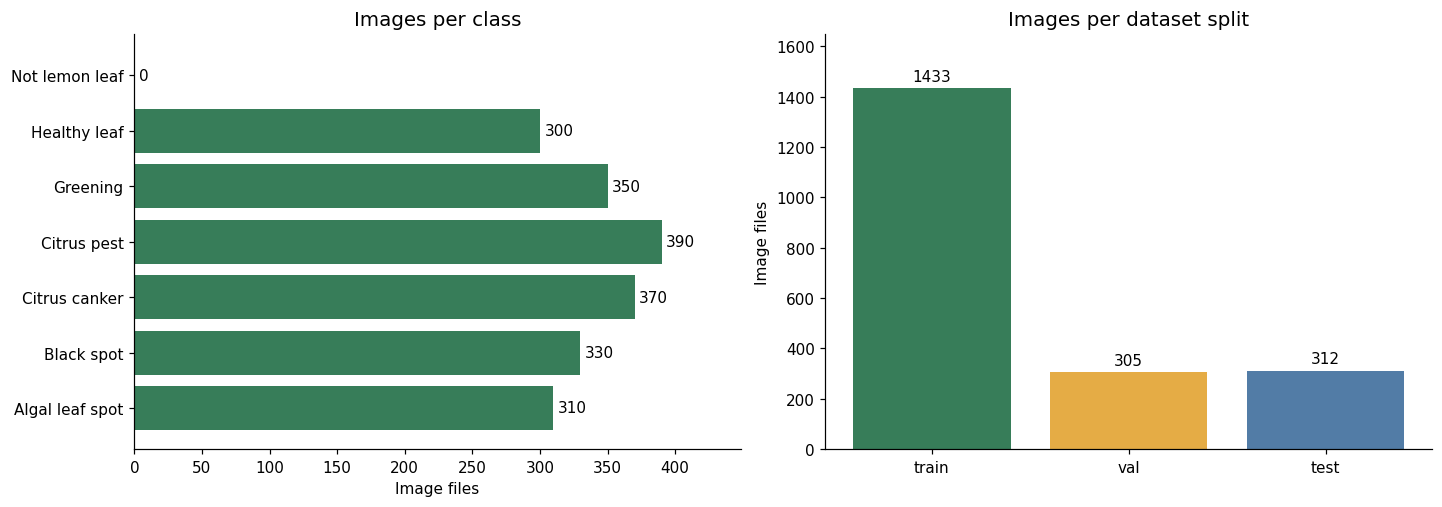

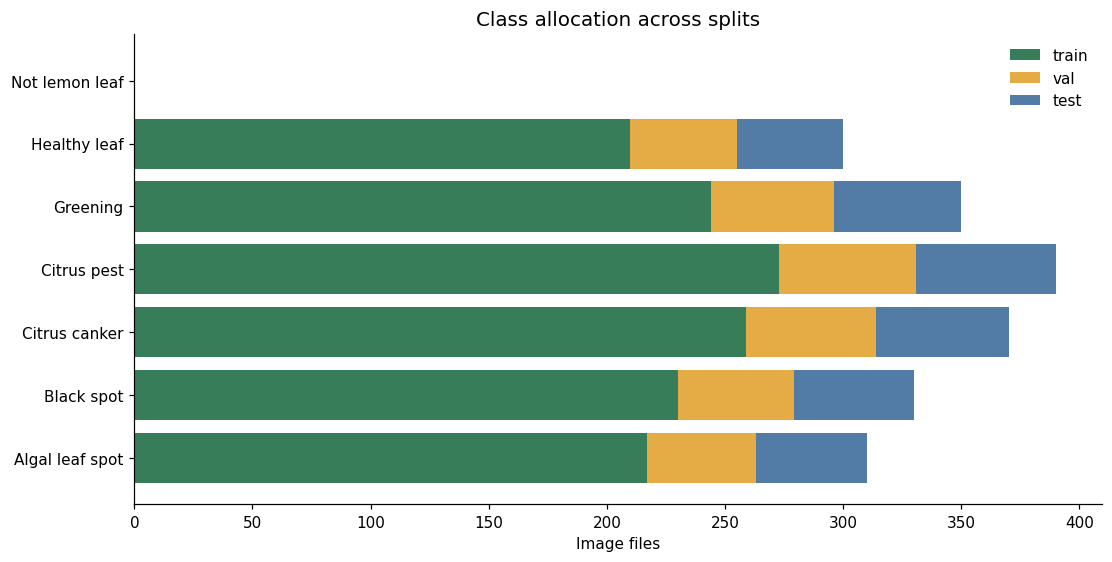

In [5]:
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "axes.titlesize": 13})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
bars = axes[0].barh(CLASSES, class_summary["total"], color="#377d59")
axes[0].bar_label(bars, padding=3)
axes[0].set(title="Images per class", xlabel="Image files")
axes[0].margins(x=0.15)
bars = axes[1].bar(SPLITS, split_summary["images"], color=["#377d59", "#e5ac45", "#527ca6"])
axes[1].bar_label(bars, padding=3)
axes[1].set(title="Images per dataset split", ylabel="Image files")
axes[1].margins(y=0.15)
plt.show()
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
left = np.zeros(len(CLASSES))
for split, color in zip(SPLITS, ["#377d59", "#e5ac45", "#527ca6"]):
    values = class_split[split].to_numpy()
    ax.barh(CLASSES, values, left=left, label=split, color=color)
    left += values
ax.set(title="Class allocation across splits", xlabel="Image files")
ax.legend(frameon=False)
plt.show()


## 5. Image integrity and unusual properties
Unusual does **not** mean corrupt. Review flags are explicit: mode other than RGB, minimum dimension below 80 px, maximum dimension above 6,000 px, aspect ratio above 3:1, multiple frames, or Pillow warnings. These are screening rules rather than dataset corrections. Decoding errors are listed independently.


In [6]:
def image_review_flags(row):
    flags = []
    if not row.decode_ok:
        flags.append("decode failure")
    if pd.notna(row.mode) and row.mode != "RGB":
        flags.append("non-RGB mode")
    if pd.notna(row.width) and pd.notna(row.height):
        low, high = min(row.width, row.height), max(row.width, row.height)
        if low < MIN_DIMENSION: flags.append("small resolution")
        if high > MAX_DIMENSION: flags.append("large resolution")
        if low and high / low > MAX_ASPECT_RATIO: flags.append("extreme aspect ratio")
    if pd.notna(row.frames) and row.frames > 1: flags.append("multiple frames")
    if row.pillow_warnings: flags.append("Pillow warning")
    return "; ".join(flags)


integrity = inventory.copy()
integrity["review_flags"] = [image_review_flags(row) for row in inventory.itertuples(index=False)]
problem_images = integrity.loc[integrity["review_flags"] != ""]
problem_images.to_csv(REPORT_DIR / "problematic_images.csv", index=False)
print(f"Decoded: {int(inventory['decode_ok'].sum()):,}; corrupt/unreadable: {int((~inventory['decode_ok']).sum()):,}")
display(inventory.groupby("mode", dropna=False).size().rename("images").to_frame())
display(inventory.groupby(["width", "height"], dropna=False).size().sort_values(ascending=False).rename("images").to_frame().head(20))
display(problem_images[["filepath", "width", "height", "mode", "review_flags", "error"]])


Decoded: 2,050; corrupt/unreadable: 0


,images
mode,
RGB,2050


,,images
width,height,
560,420,2028
4032,3024,20
853,640,2


,filepath,width,height,mode,review_flags,error


## 6. Exact duplicates ? confirmed byte matches
SHA-256 groups can have both within-split and cross-split membership. The summary counts unique hashes with each property separately; these counts are not necessarily additive. Cross-class matches are also flagged as potential labeling conflicts. Cross-split matches compromise split independence and must be reviewed before the next evaluation.


In [7]:
hashed = inventory.loc[inventory["sha256"].notna()]
duplicate_rows = []
within_hashes, cross_hashes = set(), set()
for digest, group in hashed.groupby("sha256", sort=True):
    if len(group) < 2:
        continue
    counts = group["split"].value_counts()
    within = bool((counts > 1).any())
    cross = group["split"].nunique() > 1
    if within: within_hashes.add(digest)
    if cross: cross_hashes.add(digest)
    for row in group.to_dict("records"):
        duplicate_rows.append({"sha256": digest, "split": row["split"], "class": row["class"],
                               "filename": row["filename"], "filepath": row["filepath"],
                               "group_size": len(group), "within_split_duplicate": within,
                               "cross_split_duplicate": cross, "cross_class_match": group["class"].nunique() > 1,
                               "copies_in_this_split": int(counts[row["split"]])})
exact_columns = ["sha256", "split", "class", "filename", "filepath", "group_size", "within_split_duplicate", "cross_split_duplicate", "cross_class_match", "copies_in_this_split"]
exact_duplicates = pd.DataFrame(duplicate_rows, columns=exact_columns)
exact_duplicates.to_csv(REPORT_DIR / "exact_duplicates.csv", index=False)
print(f"Exact within-split duplicate groups: {len(within_hashes)}")
print(f"EXACT CROSS-SPLIT DUPLICATE GROUPS: {len(cross_hashes)}")
display(exact_duplicates)
if cross_hashes:
    display(Markdown("**Confirmed cross-split byte matches ? leakage review required:**"))
    display(exact_duplicates.loc[exact_duplicates["cross_split_duplicate"] == True])


Exact within-split duplicate groups: 2
EXACT CROSS-SPLIT DUPLICATE GROUPS: 1


,sha256,split,class,filename,filepath,group_size,within_split_duplicate,cross_split_duplicate,cross_class_match,copies_in_this_split
0,22ffa7cc48bd89d39161f5dff67f7e1770f1bb11f059b7...,val,Healthy leaf,2025_11_21_IMG (74).JPG,dataset/val/Healthy leaf/2025_11_21_IMG (74).JPG,2,True,False,False,2
1,22ffa7cc48bd89d39161f5dff67f7e1770f1bb11f059b7...,val,Healthy leaf,2025_11_21_IMG (75).JPG,dataset/val/Healthy leaf/2025_11_21_IMG (75).JPG,2,True,False,False,2
2,e00491d4fb1666b6645d7c4dc6579a105422593d0d2e4a...,train,Healthy leaf,2025_11_21_IMG (281).JPG,dataset/train/Healthy leaf/2025_11_21_IMG (281...,2,True,False,False,2
3,e00491d4fb1666b6645d7c4dc6579a105422593d0d2e4a...,train,Healthy leaf,2025_11_21_IMG (282).JPG,dataset/train/Healthy leaf/2025_11_21_IMG (282...,2,True,False,False,2
4,f20573097807823fa7d8ca6d06cb70cc716858f4b9dd5f...,val,Healthy leaf,2025_11_21_IMG (136).JPG,dataset/val/Healthy leaf/2025_11_21_IMG (136).JPG,2,False,True,False,1
5,f20573097807823fa7d8ca6d06cb70cc716858f4b9dd5f...,test,Healthy leaf,2025_11_21_IMG (135).JPG,dataset/test/Healthy leaf/2025_11_21_IMG (135)...,2,False,True,False,1


**Confirmed cross-split byte matches ? leakage review required:**

,sha256,split,class,filename,filepath,group_size,within_split_duplicate,cross_split_duplicate,cross_class_match,copies_in_this_split
4,f20573097807823fa7d8ca6d06cb70cc716858f4b9dd5f...,val,Healthy leaf,2025_11_21_IMG (136).JPG,dataset/val/Healthy leaf/2025_11_21_IMG (136).JPG,2,False,True,False,1
5,f20573097807823fa7d8ca6d06cb70cc716858f4b9dd5f...,test,Healthy leaf,2025_11_21_IMG (135).JPG,dataset/test/Healthy leaf/2025_11_21_IMG (135)...,2,False,True,False,1


## 7. Near-duplicate candidates requiring manual review
A 64-bit difference hash compares adjacent grayscale pixels after EXIF normalization and resizing to 9?8. Cross-split pairs with Hamming distance ?6 are retained, excluding confirmed byte-identical pairs. `similarity_score = 1 - distance / 64` is a hash similarity score, **not** a duplicate probability.

The algorithm compares each pair of splits using vectorized XOR and byte-popcount; memory is linear in the size of the compared split, rather than constructing a full image-pair tensor. It is practical for approximately 2,050 files. It can miss crops, rotations, and lighting changes and can flag visually simple but unrelated images. All classes are compared, including possible label conflicts.


In [8]:
def difference_hash(path):
    with Image.open(path) as image:
        normalized = ImageOps.exif_transpose(image).convert("L")
        pixels = np.asarray(normalized.resize((DHASH_SIZE + 1, DHASH_SIZE), Image.Resampling.LANCZOS))
    return np.packbits(pixels[:, 1:] > pixels[:, :-1]).astype(np.uint8)


hash_rows, perceptual_errors = [], []
for row in inventory.loc[inventory["decode_ok"]].to_dict("records"):
    try:
        row["dhash_bytes"] = difference_hash(PROJECT_ROOT / row["filepath"])
        hash_rows.append(row)
    except (OSError, ValueError, Image.DecompressionBombError) as exc:
        perceptual_errors.append({"filepath": row["filepath"], "error": f"{type(exc).__name__}: {exc}"})
pd.DataFrame(perceptual_errors, columns=["filepath", "error"]).to_csv(REPORT_DIR / "perceptual_hash_errors.csv", index=False)
POPCOUNT = np.array([bin(value).count("1") for value in range(256)], dtype=np.uint8)


def pair_details(first, second):
    return {f"{field}_{side}": row[field] for side, row in (("a", first), ("b", second))
            for field in ("filepath", "filename", "split", "class")}


near_rows = []
for split_a, split_b in combinations(SPLITS, 2):
    first_rows = [row for row in hash_rows if row["split"] == split_a]
    second_rows = [row for row in hash_rows if row["split"] == split_b]
    if not second_rows:
        continue
    second_hashes = np.stack([row["dhash_bytes"] for row in second_rows])
    for first in first_rows:
        distances = POPCOUNT[np.bitwise_xor(second_hashes, first["dhash_bytes"])].sum(axis=1)
        for index in np.flatnonzero(distances <= NEAR_DISTANCE_MAX):
            second = second_rows[int(index)]
            if first["sha256"] == second["sha256"]:
                continue
            distance = int(distances[index])
            near_rows.append({**pair_details(first, second), "hamming_distance": distance,
                              "similarity_score": 1 - distance / 64,
                              "review_status": "near-duplicate candidate requiring manual review"})
pair_columns = [f"{field}_{side}" for side in ("a", "b") for field in ("filepath", "filename", "split", "class")]
near_candidates = pd.DataFrame(near_rows, columns=pair_columns + ["hamming_distance", "similarity_score", "review_status"])
near_candidates = near_candidates.sort_values(["hamming_distance", "filepath_a", "filepath_b"]).reset_index(drop=True)
near_candidates.to_csv(REPORT_DIR / "near_duplicate_candidates.csv", index=False)
print(f"Near-duplicate candidates requiring manual review: {len(near_candidates):,}")
print(f"Perceptual hash failures: {len(perceptual_errors)}")
display(near_candidates.head(20))


Near-duplicate candidates requiring manual review: 476
Perceptual hash failures: 0


,filepath_a,filename_a,split_a,class_a,filepath_b,filename_b,split_b,class_b,hamming_distance,similarity_score,review_status
0,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (1).JPG,train,Algal leaf spot,dataset/test/Algal leaf spot/2025_12_21_IMG (3...,2025_12_21_IMG (310).JPG,test,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
1,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (137).JPG,train,Algal leaf spot,dataset/val/Algal leaf spot/2025_12_21_IMG (13...,2025_12_21_IMG (136).JPG,val,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
2,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (175).JPG,train,Algal leaf spot,dataset/val/Algal leaf spot/2025_12_21_IMG (17...,2025_12_21_IMG (174).JPG,val,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
3,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (186).JPG,train,Algal leaf spot,dataset/val/Algal leaf spot/2025_12_21_IMG (18...,2025_12_21_IMG (187).JPG,val,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
4,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (198).JPG,train,Algal leaf spot,dataset/test/Algal leaf spot/2025_12_21_IMG (1...,2025_12_21_IMG (199).JPG,test,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
5,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (207).JPG,train,Algal leaf spot,dataset/test/Algal leaf spot/2025_12_21_IMG (2...,2025_12_21_IMG (206).JPG,test,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
6,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (207).JPG,train,Algal leaf spot,dataset/val/Algal leaf spot/2025_12_21_IMG (20...,2025_12_21_IMG (205).JPG,val,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
7,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (279).JPG,train,Algal leaf spot,dataset/val/Algal leaf spot/2025_12_21_IMG (27...,2025_12_21_IMG (278).JPG,val,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
8,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (280).JPG,train,Algal leaf spot,dataset/val/Algal leaf spot/2025_12_21_IMG (27...,2025_12_21_IMG (278).JPG,val,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review
9,dataset/train/Algal leaf spot/2025_12_21_IMG (...,2025_12_21_IMG (77).JPG,train,Algal leaf spot,dataset/test/Algal leaf spot/2025_12_21_IMG (7...,2025_12_21_IMG (78).JPG,test,Algal leaf spot,0,1.0,near-duplicate candidate requiring manual review


## 8. Visual duplicate review
Review pair images, not filenames alone. Exact groups are represented by a pair that spans splits where possible; all members remain available in the CSV. Up to eight exact groups and eight strongest near-candidate pairs are shown deterministically. No review decisions or corrections are automatically applied.


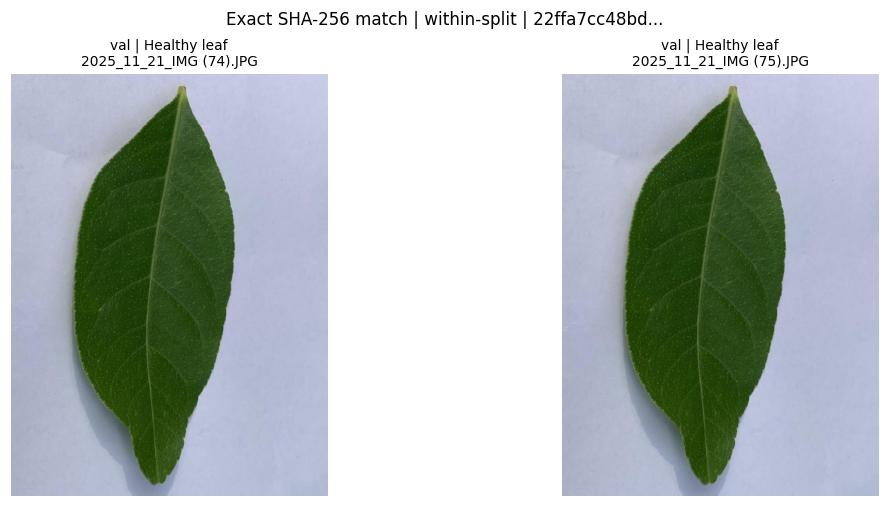

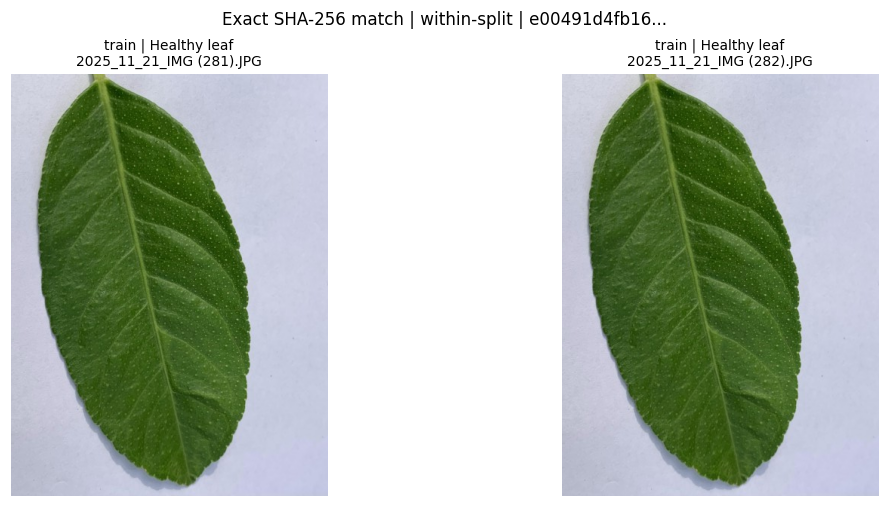

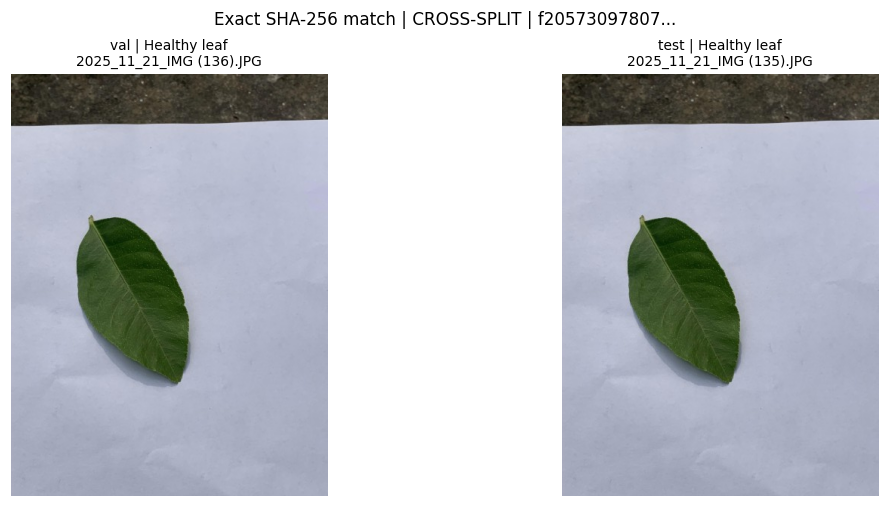

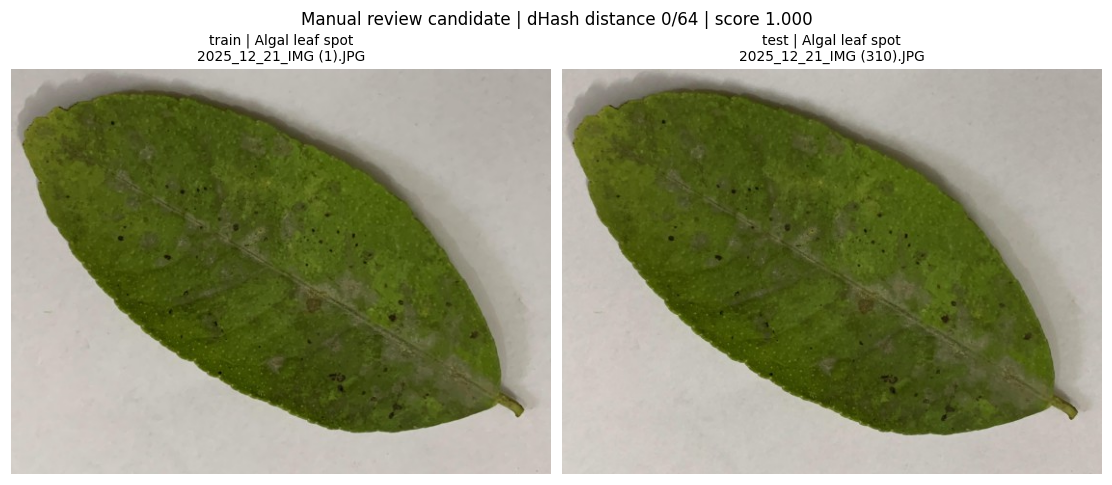

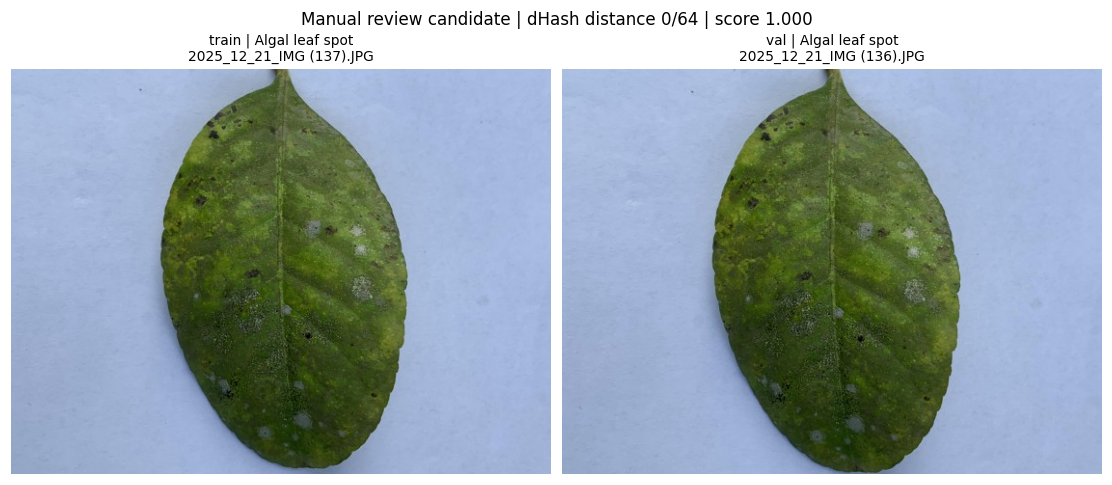

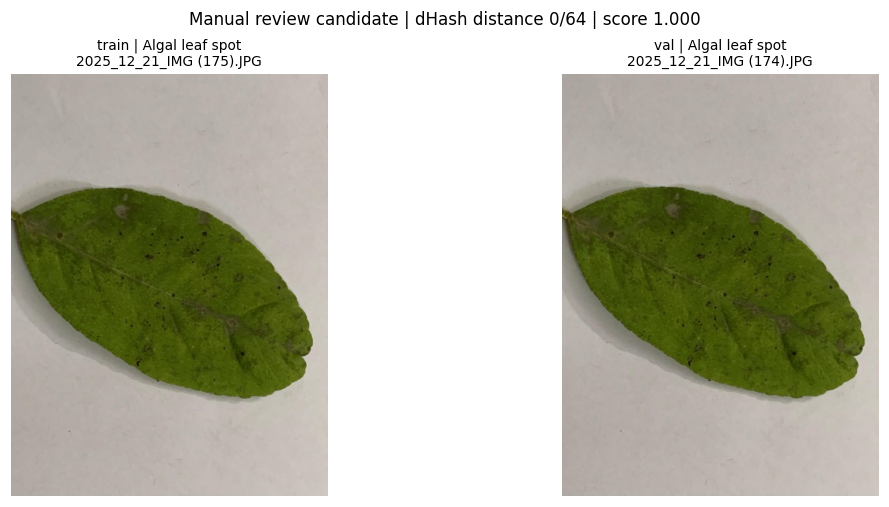

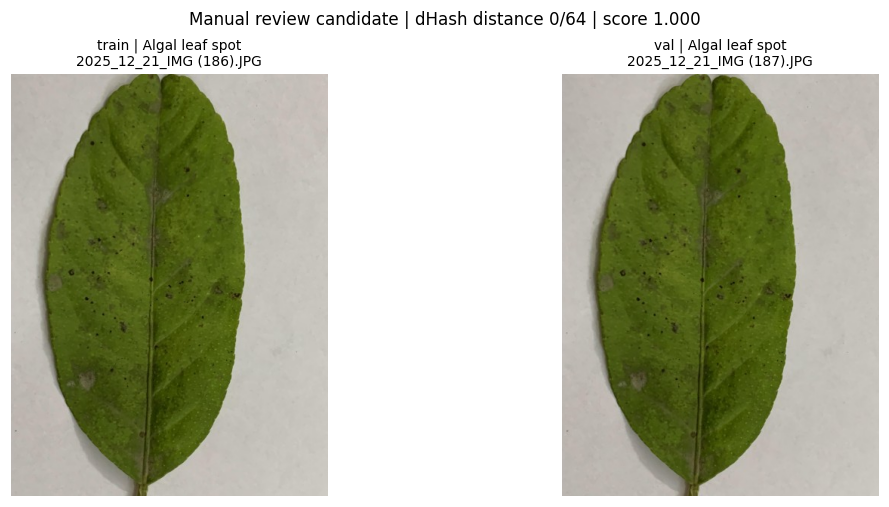

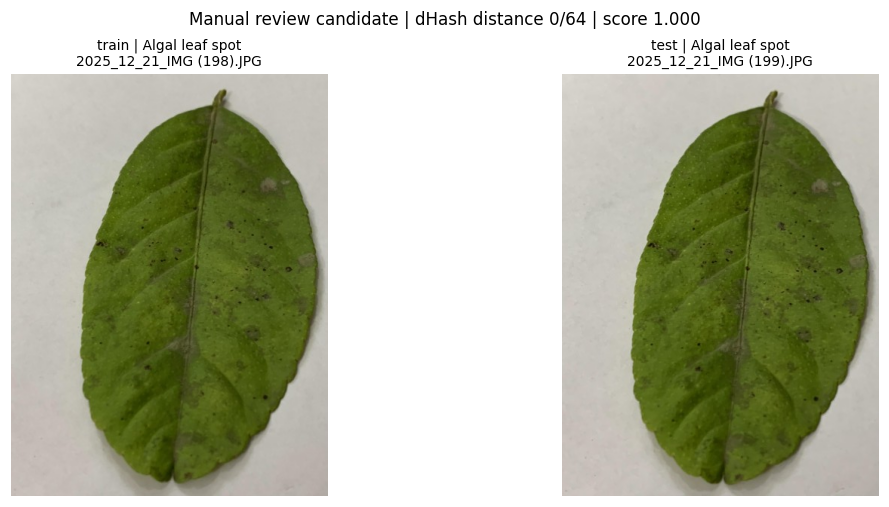

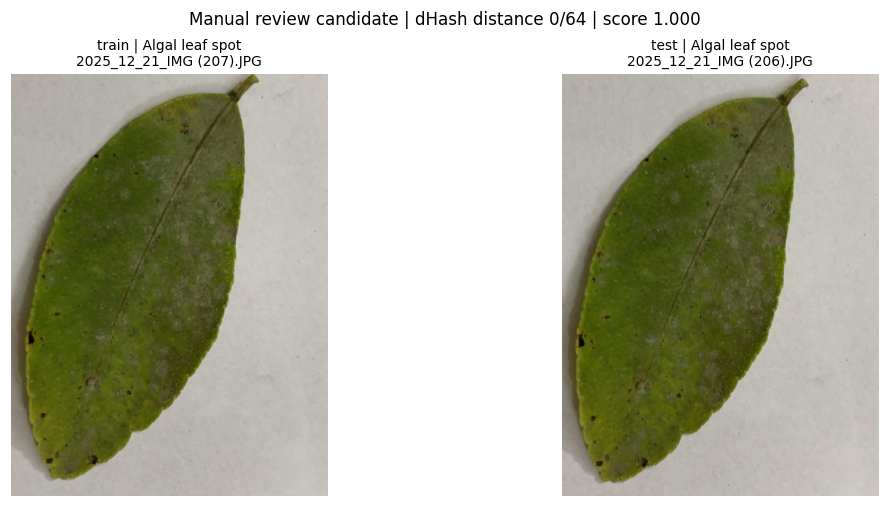

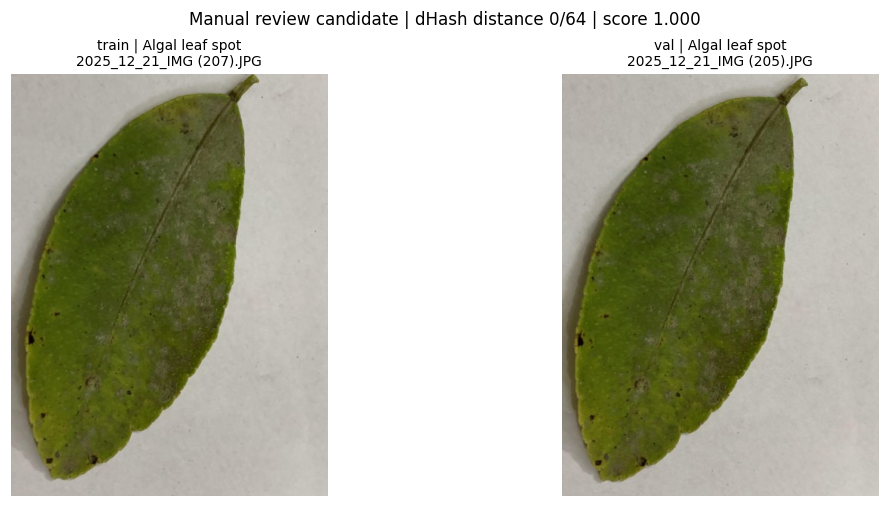

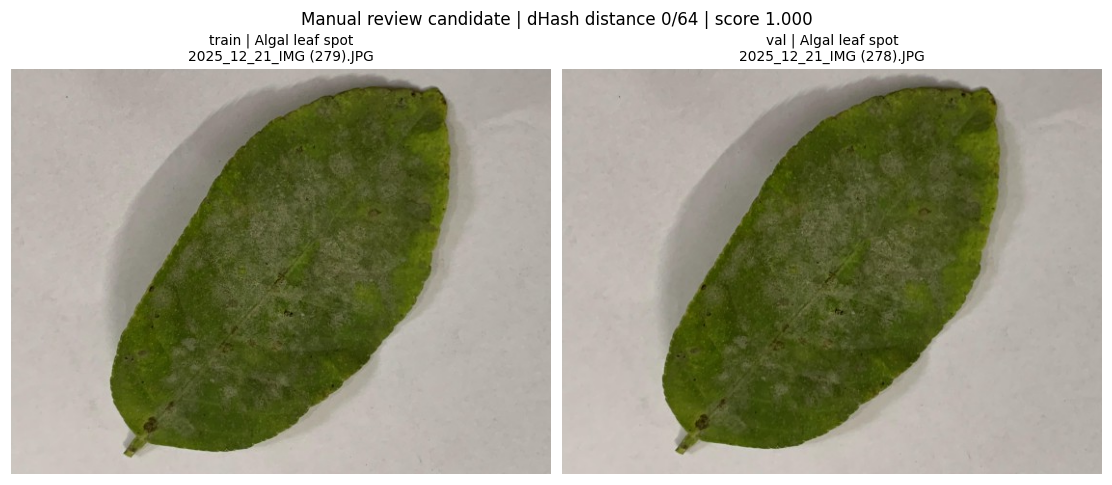

In [9]:
def show_review_pair(first, second, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")
    for ax, row in zip(axes, (first, second)):
        try:
            with Image.open(PROJECT_ROOT / row["filepath"]) as image:
                preview = ImageOps.exif_transpose(image).convert("RGB")
                preview.thumbnail((700, 700))
                ax.imshow(preview)
        except (OSError, ValueError, Image.DecompressionBombError) as exc:
            ax.text(0.5, 0.5, f"Cannot preview: {type(exc).__name__}", ha="center")
        ax.set_title(f"{row['split']} | {row['class']}\n{row['filename']}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    plt.show()


for digest, group in list(exact_duplicates.groupby("sha256", sort=True))[:MAX_REVIEW_PAIRS]:
    rows = group.to_dict("records")
    first = rows[0]
    second = next((row for row in rows[1:] if row["split"] != first["split"]), rows[1])
    scope = "CROSS-SPLIT" if first["split"] != second["split"] else "within-split"
    show_review_pair(first, second, f"Exact SHA-256 match | {scope} | {digest[:12]}...")
for row in near_candidates.head(MAX_REVIEW_PAIRS).to_dict("records"):
    first = {field: row[f"{field}_a"] for field in ("filepath", "filename", "split", "class")}
    second = {field: row[f"{field}_b"] for field in ("filepath", "filename", "split", "class")}
    show_review_pair(first, second, f"Manual review candidate | dHash distance {row['hamming_distance']}/64 | score {row['similarity_score']:.3f}")


## 9. Filename / capture-pattern investigation
Extract date-like prefixes and `IMG` sequence numbers. Within each class and date-like token, consecutive numbered files form potential capture-group candidates. Only groups spanning multiple splits are highlighted. Same-number files remain in a group. Dates are tokens, not authenticated capture timestamps; numbers can reset or be copied. Consecutive filenames do **not** prove leakage. Source records, EXIF metadata, and visual inspection are needed to confirm shared leaves or capture sessions. Files without these patterns remain visible through coverage counts.


In [10]:
def filename_tokens(filename):
    date = re.search(r"(?<!\d)((?:19|20)\d{2})[-_](\d{2})[-_](\d{2})(?!\d)", filename)
    number = re.search(r"\bIMG[ _(-]*(\d+)", filename, flags=re.IGNORECASE)
    # Underscore is a word character, so also accept the common _IMG prefix.
    if number is None:
        number = re.search(r"(?:^|_)IMG[ _(-]*(\d+)", filename, flags=re.IGNORECASE)
    return ("-".join(date.groups()) if date else None, int(number.group(1)) if number else None)


capture_inventory = inventory[["filepath", "filename", "class", "split"]].copy()
tokens = [filename_tokens(name) for name in capture_inventory["filename"]]
capture_inventory["date_token"] = [token[0] for token in tokens]
capture_inventory["image_number"] = pd.array([token[1] for token in tokens], dtype="Int64")
capture_inventory.to_csv(REPORT_DIR / "filename_patterns.csv", index=False)
matched = capture_inventory.dropna(subset=["date_token", "image_number"])
capture_rows = []
for (class_name, date_token), group in matched.groupby(["class", "date_token"], sort=True):
    ordered = group.sort_values(["image_number", "filepath"])
    sequence_ids = ordered["image_number"].diff().gt(CAPTURE_NUMBER_GAP).fillna(False).cumsum()
    for _, sequence in ordered.groupby(sequence_ids, sort=True):
        if len(sequence) < 2 or sequence["split"].nunique() < 2:
            continue
        group_id = f"capture_{len(capture_rows) + 1:04d}"
        capture_rows.append({"group_id": group_id, "class": class_name, "date_token": date_token,
                             "first_image_number": int(sequence["image_number"].min()),
                             "last_image_number": int(sequence["image_number"].max()),
                             "image_count": len(sequence), "splits": "|".join(sorted(sequence["split"].unique())),
                             "filepaths": json.dumps(sequence["filepath"].tolist()),
                             "review_status": "potential capture-group candidate requiring manual review"})
capture_columns = ["group_id", "class", "date_token", "first_image_number", "last_image_number", "image_count", "splits", "filepaths", "review_status"]
capture_candidates = pd.DataFrame(capture_rows, columns=capture_columns)
capture_candidates.to_csv(REPORT_DIR / "capture_group_candidates.csv", index=False)
print(f"Files with both recognized tokens: {len(matched):,} / {len(inventory):,}")
print(f"Potential cross-split capture-group candidates requiring manual review: {len(capture_candidates):,}")
display(capture_candidates.drop(columns="filepaths"))


Files with both recognized tokens: 2,050 / 2,050
Potential cross-split capture-group candidates requiring manual review: 6


,group_id,class,date_token,first_image_number,last_image_number,image_count,splits,review_status
0,capture_0001,Algal leaf spot,2025-12-21,1,310,310,test|train|val,potential capture-group candidate requiring ma...
1,capture_0002,Black spot,2025-12-20,1,330,330,test|train|val,potential capture-group candidate requiring ma...
2,capture_0003,Citrus canker,2025-12-21,202,571,370,test|train|val,potential capture-group candidate requiring ma...
3,capture_0004,Citrus pest,2025-12-20,18,407,390,test|train|val,potential capture-group candidate requiring ma...
4,capture_0005,Greening,2025-12-21,1,350,350,test|train|val,potential capture-group candidate requiring ma...
5,capture_0006,Healthy leaf,2025-11-21,1,300,300,test|train|val,potential capture-group candidate requiring ma...


## 10. Machine-generated leakage summary and JSON export
The summary records thresholds, versions, and a deterministic inventory fingerprint. Counts of near candidates are image pairs, while exact and capture counts are groups. They overlap and must not be added together. `empty_classes` means classes with zero images across all splits; `empty_class_folders` gives split-level details. A clean exact-duplicate check alone cannot establish capture independence.


In [11]:
fingerprint_text = "\n".join(f"{row.filepath}\t{row.sha256}" for row in inventory.sort_values("filepath").itertuples(index=False))
summary = {
    "audit_schema_version": 1,
    "dataset_root": "dataset",
    "inventory_fingerprint_sha256": hashlib.sha256(fingerprint_text.encode("utf-8")).hexdigest(),
    "total_images": len(inventory),
    "valid_images": int(inventory["decode_ok"].sum()),
    "corrupt_images": int((~inventory["decode_ok"]).sum()),
    "images_with_review_flags": len(problem_images),
    "images_per_split": {split: int(split_summary.loc[split, "images"]) for split in SPLITS},
    "images_per_class": {name: int(class_summary.loc[name, "total"]) for name in CLASSES},
    "exact_duplicate_groups_total": int(exact_duplicates["sha256"].nunique()),
    "exact_within_split_duplicate_groups": len(within_hashes),
    "exact_cross_split_duplicate_groups": len(cross_hashes),
    "exact_cross_class_duplicate_groups": int(exact_duplicates.loc[exact_duplicates["cross_class_match"] == True, "sha256"].nunique()),
    "near_duplicate_candidates": len(near_candidates),
    "perceptual_hash_failures": len(perceptual_errors),
    "empty_classes": class_summary.index[class_summary["total"] == 0].tolist(),
    "empty_class_folders": folder_inventory.loc[folder_inventory["empty_class"], ["split", "class"]].to_dict("records"),
    "missing_class_folders": folder_inventory.loc[~folder_inventory["exists"], ["split", "class"]].to_dict("records"),
    "suspicious_capture_pattern_groups": len(capture_candidates),
    "filename_pattern_matched_images": len(matched),
    "non_image_or_unassigned_files": len(non_image_files),
    "parameters": {"seed": SEED, "dhash_size": DHASH_SIZE, "near_distance_max": NEAR_DISTANCE_MAX,
                   "min_dimension": MIN_DIMENSION, "max_dimension": MAX_DIMENSION,
                   "max_aspect_ratio": MAX_ASPECT_RATIO, "capture_number_gap": CAPTURE_NUMBER_GAP,
                   "supported_extensions": sorted(IMAGE_EXTENSIONS)},
    "environment": {"python": platform.python_version(), **versions},
    "interpretation": "Exact SHA-256 matches identify byte-identical files. Near-duplicate and capture-group candidates require human verification; neither proves leakage. No dataset corrections were performed."
}
(REPORT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
display(pd.Series({key: summary[key] for key in ["total_images", "valid_images", "corrupt_images", "exact_within_split_duplicate_groups", "exact_cross_split_duplicate_groups", "near_duplicate_candidates", "suspicious_capture_pattern_groups"]}, name="count").to_frame())
print("Empty classes:", summary["empty_classes"])
print(summary["interpretation"])
print("Reports saved to:", REPORT_DIR)


,count
total_images,2050
valid_images,2050
corrupt_images,0
exact_within_split_duplicate_groups,2
exact_cross_split_duplicate_groups,1
near_duplicate_candidates,476
suspicious_capture_pattern_groups,6


Empty classes: ['Not lemon leaf']
Exact SHA-256 matches identify byte-identical files. Near-duplicate and capture-group candidates require human verification; neither proves leakage. No dataset corrections were performed.
Reports saved to: E:\LemoScan-AI\reports\dataset_audit


## 11. Review priorities and audit boundaries
1. Review confirmed cross-split byte matches and any cross-class label conflicts first.
2. Inspect near-candidate pairs and filename groups against original acquisition records; record human decisions before changing the dataset.
3. Decide how to group related captures when constructing a future split. Preserve the current dataset until a separate correction task is authorized.
4. Resolve empty classes and unreadable files before future training.

This audit does not validate disease labels, prove species identity, establish dataset licensing, reproduce model accuracy, or exhaustively detect all near-duplicates. No automated cleanup or retraining is performed. Re-running the notebook overwrites only its generated report files.
